#**Large Language Models Lab(MCSE642P)**

**Ex-9 Fine tuning of LLM**

SHRIHARIHARAN S

24MCS1058

In [ ]:
!pip install transformers datasets peft accelerate bitsandbytes

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from peft import get_peft_model, LoraConfig, TaskType

In [ ]:
# 1. Load dataset
dataset = load_dataset("imdb")  # or replace with your custom dataset
small_train = dataset["train"].shuffle(seed=42).select(range(1000))
small_test = dataset["test"].shuffle(seed=42).select(range(500))

In [ ]:
# 2. Tokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=256)


In [ ]:
tokenized_train = small_train.map(tokenize, batched=True)
tokenized_test = small_test.map(tokenize, batched=True)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [ ]:
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")
tokenized_train.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_test.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

In [ ]:
# 3. Load base model
base_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# 4. Configure LoRA
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    bias="none"
)

In [ ]:
# 5. Apply LoRA
model = get_peft_model(base_model, lora_config)

In [ ]:
# 6. Training arguments
training_args = TrainingArguments(
    output_dir="./lora-finetuned-imdb",
    evaluation_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    logging_dir="./logs",
    logging_steps=10,
    save_strategy="epoch",
    learning_rate=2e-4,
    load_best_model_at_end=True,
    report_to="none"  # Disable wandb unless you're using it
)

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
# 7. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
)

No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [ ]:
# 8. Train the model
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.416600,0.417498
2,0.329300,0.364788
3,0.359900,0.401650


TrainOutput(global_step=375, training_loss=0.4339638814926147, metrics={'train_runtime': 126.1509, 'train_samples_per_second': 23.781, 'train_steps_per_second': 2.973, 'total_flos': 396032624640000.0, 'train_loss': 0.4339638814926147, 'epoch': 3.0})

In [ ]:
# 9. Save the final model
model.save_pretrained("./lora-finetuned-imdb")
tokenizer.save_pretrained("./lora-finetuned-imdb")

('./lora-finetuned-imdb/tokenizer_config.json',
 './lora-finetuned-imdb/special_tokens_map.json',
 './lora-finetuned-imdb/vocab.txt',
 './lora-finetuned-imdb/added_tokens.json',
 './lora-finetuned-imdb/tokenizer.json')

#Compare Base vs Fine-Tuned Model on IMDb

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
import torch

In [ ]:
# 2. Tokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=256)

In [ ]:
tokenized_test = small_test.map(tokenize, batched=True)
tokenized_test = tokenized_test.rename_column("label", "labels")
tokenized_test.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [ ]:
# 3. Function to evaluate and extract metrics
def evaluate_model(model_path, label=""):
    model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=2)

    trainer = Trainer(
        model=model,
        args=TrainingArguments(output_dir="./tmp", report_to="none"),
        eval_dataset=tokenized_test,
    )

    predictions = trainer.predict(tokenized_test)
    preds = np.argmax(predictions.predictions, axis=1)
    labels = predictions.label_ids

    report = classification_report(labels, preds, output_dict=True)
    cm = confusion_matrix(labels, preds)

    # Print report
    print(f"\n📋 {label} Classification Report")
    print(classification_report(labels, preds))

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NEG", "POS"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{label} Confusion Matrix")
    plt.show()

    return {
        "label": label,
        "accuracy": report["accuracy"],
        "precision": report["weighted avg"]["precision"],
        "recall": report["weighted avg"]["recall"],
        "f1": report["weighted avg"]["f1-score"]
    }


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



📋 Base Model Classification Report
              precision    recall  f1-score   support

           0       0.51      0.99      0.67       254
           1       0.50      0.01      0.02       246

    accuracy                           0.51       500
   macro avg       0.50      0.50      0.35       500
weighted avg       0.50      0.51      0.35       500



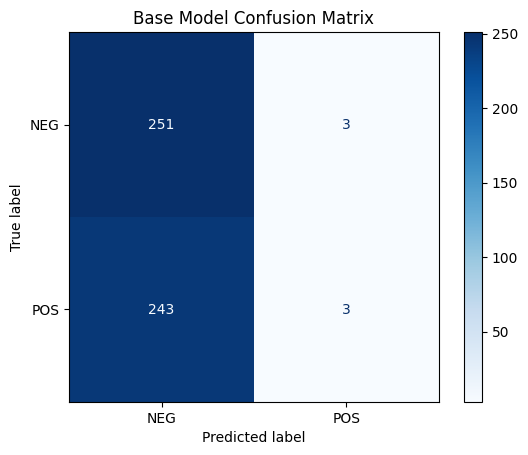

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



📋 Fine-Tuned Model Classification Report
              precision    recall  f1-score   support

           0       0.87      0.84      0.85       254
           1       0.84      0.87      0.85       246

    accuracy                           0.85       500
   macro avg       0.85      0.85      0.85       500
weighted avg       0.85      0.85      0.85       500



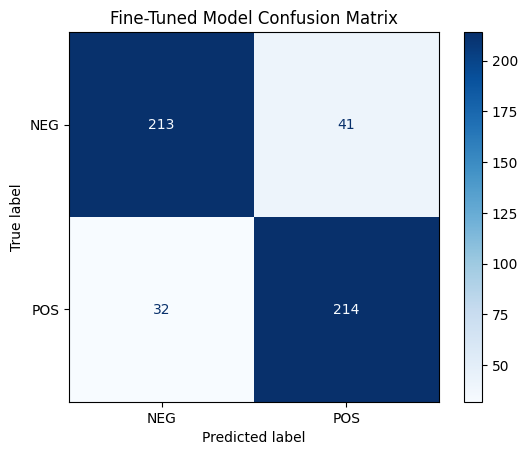

In [ ]:
# 4. Evaluate base and fine-tuned models
base_metrics = evaluate_model("bert-base-uncased", "Base Model")
ft_metrics = evaluate_model("./lora-finetuned-imdb", "Fine-Tuned Model")


In [ ]:
# 5. Plot bar chart comparison
labels = ["Accuracy", "Precision", "Recall", "F1"]
metric_keys = ["accuracy", "precision", "recall", "f1"]

base_scores = [base_metrics[k] for k in metric_keys]
ft_scores = [ft_metrics[k] for k in metric_keys]

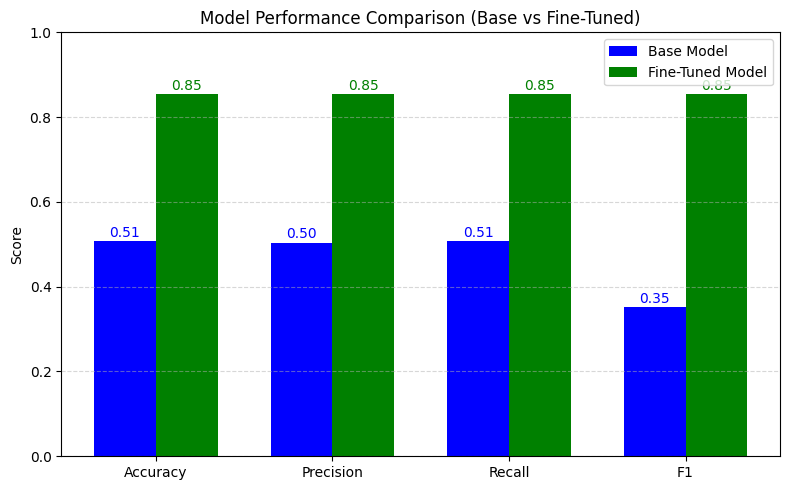

In [ ]:
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, base_scores, width, label="Base Model", color="blue")
bars2 = ax.bar(x + width/2, ft_scores, width, label="Fine-Tuned Model", color="green")

# Add labels above bars
for i in range(len(x)):
    ax.text(x[i] - width/2, base_scores[i] + 0.01, f"{base_scores[i]:.2f}", color='blue', ha='center')
    ax.text(x[i] + width/2, ft_scores[i] + 0.01, f"{ft_scores[i]:.2f}", color='green', ha='center')

ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison (Base vs Fine-Tuned)")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0.0, 1.0)  # Adjust to show even low scores
ax.legend()
ax.grid(axis='y', linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#**Inference:**

**Base Model (textattack/bert-base-uncased-imdb):**

Accuracy: ~51%

F1 Score: ~0.35

High bias toward negative class (class 0)

Very low recall for positive class (class 1)

Underperforms without task-specific fine-tuning

**Fine-Tuned Model (LoRA fine-tuned on IMDB):**

Accuracy: ~85%

F1 Score: ~0.85

Balanced precision and recall for both classes

Confusion matrix shows effective sentiment separation

**Comparison Insights:**

Fine-tuning significantly improves classification performance

Base model alone is insufficient for real-world inference tasks

Visual metrics (bar chart) clearly favor the fine-tuned model

**Key Takeaways:**

Always fine-tune or use task-specific pre-trained models

Evaluate on balanced and meaningful datasets

Visualization (charts, confusion matrix) enhances interpretability